# Access free ERA5 data
Example ERA5 data access without a cloud account. It opens the public ARCO ERA5 Zarr archive on Google Cloud anonymously, subsets it over an Antarctic bbox, and plots 2 m air temperature.

Official sources:
- ERA5 on the Copernicus Climate Data Store: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels
- ECMWF ERA5 data documentation: https://confluence.ecmwf.int/spaces/CKB/pages/76414402/ERA5+data+documentation
- Google Cloud public datasets page: https://docs.cloud.google.com/storage/docs/public-datasets
- Google Research ARCO ERA5 access examples: https://github.com/google-research/arco-era5

In [53]:
import fsspec
import numpy as np
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from pyproj import Transformer
import jupyter_bokeh

import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pystac_client import Client as pystac_client
from odc.stac import stac_load

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

from shapely.geometry import mapping, box, shape


# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-2_300_000.0, 1000_000.0)
ROI_HALF_WIDTH_CELLS = 4000
CUBE_RES_M = 100

cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * CUBE_RES_M


antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [54]:
to_lonlat = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

corners_3031 = [
    (cx - half, cy - half),
    (cx - half, cy + half),
    (cx + half, cy - half),
    (cx + half, cy + half),
]

corners_lonlat = [to_lonlat.transform(x, y) for x, y in corners_3031]

bbox = [
    min(lon for lon, lat in corners_lonlat),
    min(lat for lon, lat in corners_lonlat),
    max(lon for lon, lat in corners_lonlat),
    max(lat for lon, lat in corners_lonlat),
]

bbox

[-77.47119229084849,
 -71.81000215448617,
 -53.615648184164115,
 -62.52573259978129]

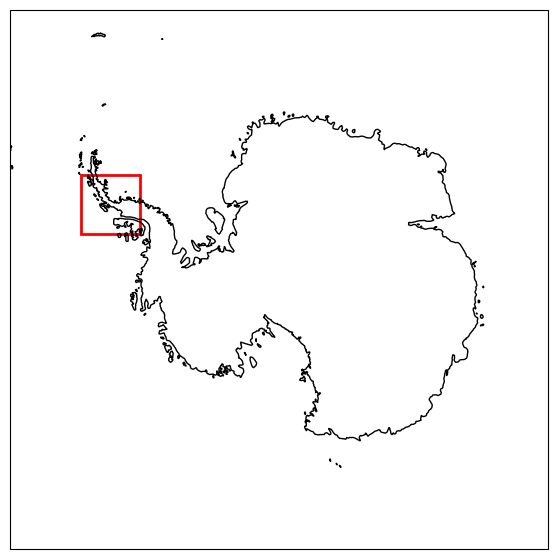

In [55]:
# Convert ROI center from meters to the appropriate scale and calculate half-width
cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * 100 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -58], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_patch(Rectangle((cx - half, cy - half), 2 * half, 2 * half, fill=False, edgecolor="red", linewidth=2, transform=ax.projection))
plt.show()


In [56]:
cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr",
]

ds = xr.open_mfdataset(cube_paths, engine="zarr", chunks={}, compat="no_conflicts")

x_index = int(np.abs(ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)

ds = ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})

ds


<xarray.Dataset> Size: 155GB
Dimensions:                                       (y: 8001, x: 8001, depth: 91,
                                                   time_period: 27, time: 48)
Coordinates:
  * y                                             (y) float32 32kB 6e+05 ... ...
  * x                                             (x) float32 32kB -2.7e+06 ....
  * depth                                         (depth) int16 182B 0 ... 4500
  * time_period                                   (time_period) int64 216B 0 ...
  * time                                          (time) datetime64[ns] 384B ...
    spatial_ref                                   int64 8B 0
Data variables: (12/40)
    englacial_temp_profile_quality_flag           (y, x) float16 128MB dask.array<chunksize=(8001, 8001), meta=np.ndarray>
    englacial_temp_profile_tice                   (depth, y, x) float16 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    surface_elevation_change_basin_id             (y, x) float32 256MB dask.array<chunksize=(8001, 8001), meta=np.ndarray>
    surface_elevation_change_cell_end_times       (time_period, y, x) float32 7GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    surface_elevation_change_cell_start_times     (time_period, y, x) float32 7GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    surface_elevation_change_end_time             (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                            ...
    ice_sheet_surface_velocity_easting_stddev     (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    ice_sheet_surface_velocity_magnitude          (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    ice_sheet_surface_velocity_measurement_count  (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing           (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing_stddev    (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>
    ice_sheet_surface_velocity_vertical           (time, y, x) float32 12GB dask.array<chunksize=(1, 8001, 8001), meta=np.ndarray>

## Preview calving fronts

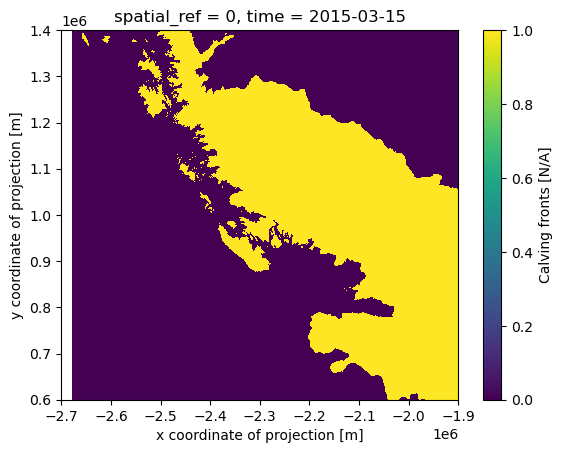

In [ ]:
ds.calving_fronts.sel(time="2015-03-01", method='nearest').plot()

## Open public ERA5

Open the public ARCO ERA5 Zarr archive directly over HTTPS in cloud-native format - Zarr

In [58]:
store = "https://storage.googleapis.com/gcp-public-data-arco-era5/ar/1959-2022-full_37-1h-0p25deg-chunk-1.zarr-v2"

mapper = fsspec.get_mapper(store)
era5_ds = xr.open_zarr(mapper, consolidated=True, chunks={})

era5_ds

<xarray.Dataset> Size: 534TB
Dimensions:                                           (time: 552264,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 37)
Coordinates:
  * time                                              (time) datetime64[ns] 4MB ...
  * latitude                                          (latitude) float32 3kB ...
  * longitude                                         (longitude) float32 6kB ...
  * level                                             (level) int64 296B 1 .....
Data variables: (12/31)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature                                    (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    geopotential                                      (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    ...                                                ...
    total_precipitation                               (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    type_of_high_vegetation                           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    type_of_low_vegetation                            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    u_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    v_component_of_wind                               (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>
    vertical_velocity                                 (time, level, latitude, longitude) float32 85TB dask.array<chunksize=(1, 37, 721, 1440), meta=np.ndarray>

## Plot one ERA5 temperature field

Subset ERA5 with the same lon/lat AOI and plot one 2 m temperature field over the cube grid.

Text(0.5, 1.0, 'ERA5 2 m temperature over Antarctic bbox, deg C')

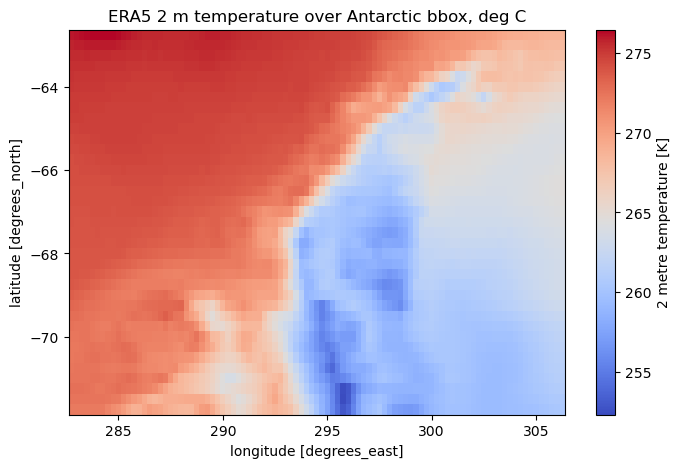

In [ ]:
# Antarctic bbox in lon/lat. ERA5 longitudes are 0..360, so convert negative longitudes.
west, south, east, north = bbox
t2m_c = era5_ds['2m_temperature'].sel(longitude=slice(west % 360, east % 360), latitude=slice(north, south), time=slice("2015-03-01", "2015-03-31")).isel(time=0) 
plt.title("ERA5 2 m temperature over Antarctic bbox")
t2m_c.rio.write_crs("EPSG:4326").rio.reproject_match(ds).plot(x="x", y="y", cmap="coolwarm", figsize=(8, 5))

## Example comparison

This is a quick exploratory example: compare coarse monthly-sampled ERA5 temperature between 1997 and 2016, then show the two calving-front positions on top.

[########################################] | 100% Completed | 8.33 ss
[########################################] | 100% Completed | 1.46 ss
[########################################] | 100% Completed | 1.15 sms


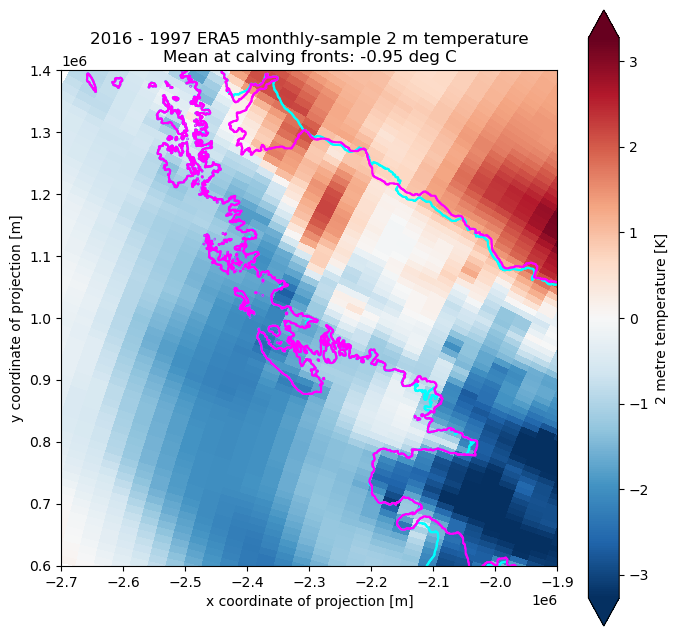

In [ ]:
# ERA5 over the same lon/lat AOI
t2m = era5_ds["2m_temperature"].sel(
    longitude=slice(west % 360, east % 360),
    latitude=slice(north, south),
)

with ProgressBar():
    # One timestep per month, then annual-ish mean
    t2m_1997 = t2m.sel(time=slice("1997-01-01", "1997-12-31")).isel(time=slice(0, None, 744)).mean("time")
    t2m_2016 = t2m.sel(time=slice("2016-01-01", "2016-12-31")).isel(time=slice(0, None, 744)).mean("time")

    t2m_change = t2m_2016 - t2m_1997

    t2m_change = (
        t2m_change
        .rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
        .rio.write_crs("EPSG:4326")
        .rio.reproject_match(ds.rio.write_crs("EPSG:3031"))
        .compute()
    )

    cf_1997 = ds.calving_fronts.sel(time="1997-01-01", method="nearest").compute()
    cf_2016 = ds.calving_fronts.sel(time="2016-01-01", method="nearest").compute()

cf_footprint = (cf_1997 > 0) | (cf_2016 > 0)
mean_change = t2m_change.where(cf_footprint).mean().item()

fig, ax = plt.subplots(figsize=(8, 8))

t2m_change.plot(ax=ax, x="x", y="y", cmap="RdBu_r", center=0, robust=True)

cf_1997.plot.contour(ax=ax, x="x", y="y", levels=[0.5], colors="cyan")
cf_2016.plot.contour(ax=ax, x="x", y="y", levels=[0.5], colors="magenta")

ax.set_title(f"2016 - 1997 ERA5 monthly-sample 2 m temperature\nMean at calving fronts: {mean_change:.2f}")
ax.set_aspect("equal")